In [2]:
from joblib import Parallel, delayed
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import pickle
import sys
from contextlib import suppress, redirect_stdout, redirect_stderr

In [3]:
%load_ext autoreload
%autoreload 2
import helper_functions as fx
import trade_functions as tf
import parse_histdata

In [3]:
parse_histdata.clean_data()

Replacing 1 rows with non-positive close prices with 0
Replacing 1 rows with close prices above 3.1232 with 1.5616
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 1.8446 with 0.9223
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 296.406 with 148.203
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 4.0662 with 2.0331
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 3.5356 with 1.7678

In [4]:
file_path = '/Volumes/SEAGATE/FX_data/FX_histdata/'
fx_pairs = ["EURUSD", "EURGBP", "USDJPY", "GBPUSD", "USDCHF", "USDCAD", "AUDUSD", "NZDUSD", "EURJPY", "GBPJPY", "EURCHF", "AUDJPY", "EURAUD", "GBPAUD"]
intervals = ['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']

In [5]:
timeline_df = parse_histdata.timeline_info(fx_pairs)
display(timeline_df)

,Pair,Start,End,Missing Minutes,Max Missing Minutes,Percentage Missing
0,EURUSD,2001-01,2023-12,305633,15547.0,2.527773
1,EURGBP,2002-03,2023-12,388973,5882.0,3.388823
2,USDJPY,2000-05,2023-12,376567,15548.0,3.036179
3,GBPUSD,2000-05,2023-12,345669,15546.0,2.787056
4,USDCHF,2000-05,2023-12,337047,19091.0,2.717530
5,USDCAD,2000-06,2023-12,505296,216573.0,4.080162
6,AUDUSD,2000-06,2023-12,417251,79473.0,3.366455
7,NZDUSD,2005-08,2023-12,301344,5883.0,3.117335
8,EURJPY,2002-03,2023-12,129127,5882.0,1.124984
9,GBPJPY,2002-05,2023-12,93632,13059.0,0.821788


### Test period : 2018-2023 (walk-forward validation)
### Training period : start - 2010 ()

* Initial Training period has only been set upto 2010, due to computational and time constraints.
* Rolling calibration will be from 2011.

Plan to use LSTM to explore pair trading between currency pairs


In [ ]:
fx.create_interval_datasets(fx_pairs, intervals, file_path)

Creating 1T datasets for all pairs
Processing EURUSD for 1T interval
Creating 1T dataset for EURUSD
Processing EURGBP for 1T interval
Creating 1T dataset for EURGBP
Processing USDJPY for 1T interval
Creating 1T dataset for USDJPY
Processing GBPUSD for 1T interval
Creating 1T dataset for GBPUSD
Processing USDCHF for 1T interval
Creating 1T dataset for USDCHF
Processing USDCAD for 1T interval
Creating 1T dataset for USDCAD
Processing AUDUSD for 1T interval
Creating 1T dataset for AUDUSD
Processing NZDUSD for 1T interval
Creating 1T dataset for NZDUSD
Processing EURJPY for 1T interval
Creating 1T dataset for EURJPY
Processing GBPJPY for 1T interval
Creating 1T dataset for GBPJPY
Processing EURCHF for 1T interval
Creating 1T dataset for EURCHF
Processing AUDJPY for 1T interval
Creating 1T dataset for AUDJPY
Processing EURAUD for 1T interval
Creating 1T dataset for EURAUD
Processing GBPAUD for 1T interval
Creating 1T dataset for GBPAUD
Creating 5T datasets for all pairs
Processing EURUSD fo

In the code above, following interpretation has been used:
For Datetime t, the data represents the period from t-1 (included) up till t (not included)
Hence while resampling, (label=right, closed=right) have been used.

In [13]:
fx.calculate_returns(fx_pairs, intervals, file_path)

Calculating returns for 1T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 5T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 10T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 15T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 30T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 1H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 3H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/1

These results suggest atleast a linear Granger-causal relationship between the various columns.

Note: 
* For 'Close', the pacf spike at lag1 and sudden drop and slow trail-off of acf indicates non-stationarity.
* For 'Return' and 'logReturn', the acf and pacf spike at lag1 indicate an ARMA(1,1) process.

In [47]:
spread_lag = spread.shift(1)
spread_ret = spread - spread_lag
spread_lag = spread_lag[1:]
spread_ret = spread_ret[1:]

half_life = -np.log(2) / fx.get_beta_lr(spread_lag, spread_ret)
print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")

Estimated Half-Life of Mean Reversion: 0.77 periods


* Initial Test period for static hedge ratios and half-lives: 2011-01-01 to 2015-12-31

In [ ]:
# Need to run this on Colab Pro (prolly A100)
res = fx.initial_granger_cointegration(fx_pairs, intervals, file_path, end_td=pd.Timedelta(days=252*5), end_max=pd.Timestamp('2010-12-31'), n_jobs=2)
with open('./temp/granger_coint_results.pkl', 'wb') as f:
    pickle.dump(res, f)

Running initial Granger cointegration tests for interval 1T...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:257: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Sign

Skipping EURUSD and USDJPY at interval 1T due to low correlation (-0.06)


[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   41.1s
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:257: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:285: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1 = forward_fill_df(df1).resample(common_freq, label='right', closed='right').agg({
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:29

Skipping EURUSD and GBPUSD at interval 1T due to low correlation (0.09)


/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:255: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=get_dynamic_freq(df.index))
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:257: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:285: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1 = forward_fill_df(df1).resample(common_freq, label='right', closed='right').agg({
/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/helper_functions.py:291: FutureWarning: 'T' is deprecated and will be removed in a 

KeyboardInterrupt: 

In [13]:
print(res)

{('AUDJPY', 'EURAUD', '6H'): 2006-01-31    2.218256e-08
2006-02-21    1.790068e-08
2006-03-14    1.841939e-08
2006-04-04    1.918772e-08
2006-04-25    2.166241e-08
                  ...     
2012-10-02    9.575926e-03
2012-10-23    1.274417e-02
2012-11-13    1.795049e-02
2012-12-04    1.921399e-02
2012-12-25    2.763536e-02
Name: pval, Length: 121, dtype: float64, ('AUDJPY', 'EURAUD', '1D'): 2006-02-01    0.000003
2006-02-22    0.000004
2006-03-15    0.000003
2006-04-05    0.000003
2006-04-26    0.000004
                ...   
2012-10-03    0.003317
2012-10-24    0.008345
2012-11-14    0.010780
2012-12-05    0.014286
2012-12-26    0.024514
Name: pval, Length: 121, dtype: float64}


<Axes: title={'center': "Rolling Engle-Granger p-values for 'AUDJPY' & 'EURAUD' - 1D"}>

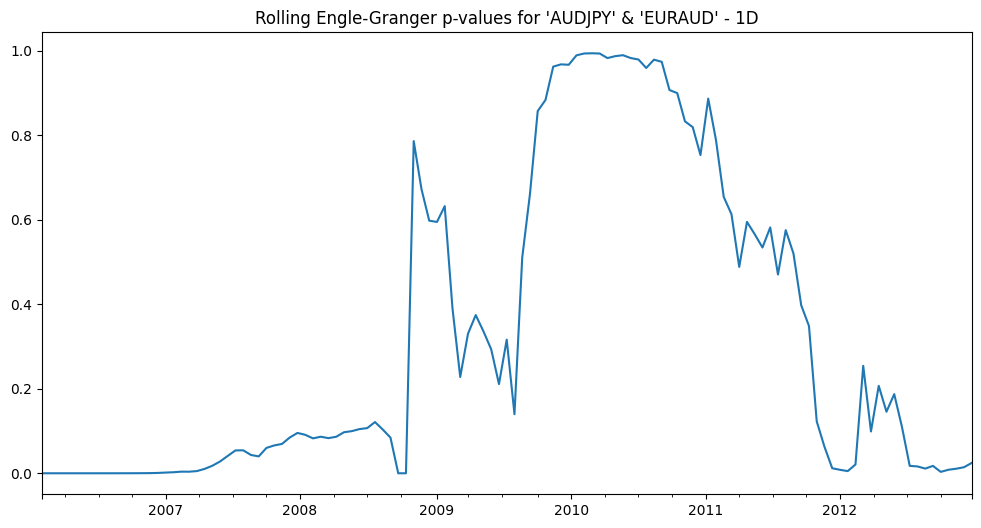

In [15]:
res[('AUDJPY', 'EURAUD', '1D')].plot(title=f"Rolling Engle-Granger p-values for 'AUDJPY' & 'EURAUD' - 1D", figsize=(12, 6))

ADF p-value: 0.6723
Estimated Half-Life of Mean Reversion: 54506.57 periods
Hedge Ratio: 0.3541


NameError: name 'spread_ret' is not defined

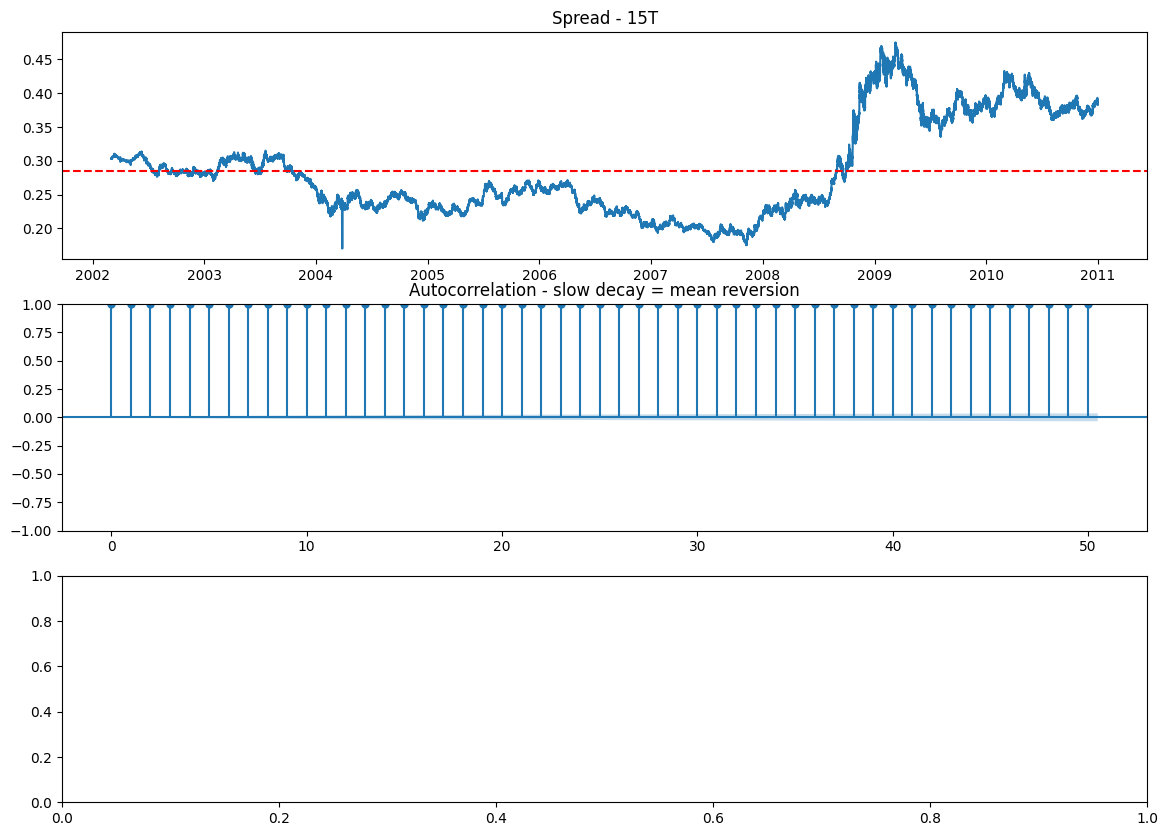

In [ ]:
# 1. Visual check - do spreads mean revert?
pair1 = eurusd_train
pair2 = eurgbp_train
def plot_spread_diagnostic(pair1, pair2, interval):

    hedge_ratio = fx.get_beta_lr(pair1['Close'], pair2['Close'])
    spread = pair2['Close'] - hedge_ratio * pair1['Close']

    # 3. The SPREAD should be stationary I(0)
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(spread.dropna(), maxlag=50)
    print(f"ADF p-value: {adf_result[1]:.4f}")
    # If p < 0.05, spread is stationary → cointegrated

    # 4. Calculate half-life on the STATIONARY spread
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread - spread_lag
    spread_ret = spread_diff.dropna()
    beta = fx.get_beta_lr(spread_lag.dropna(), spread_ret.dropna())
    half_life = -np.log(2) / beta
    print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")
    print(f"Hedge Ratio: {hedge_ratio:.4f}")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Raw spread
    axes[0].plot(spread.index, spread)
    axes[0].set_title(f'Spread - {interval}')
    axes[0].axhline(spread.mean(), color='red', linestyle='--')
    
    # ACF plot - should decay slowly if mean reverting
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(spread.dropna(), lags=50, ax=axes[1])
    axes[1].set_title('Autocorrelation - slow decay = mean reversion')
    
    # Regression
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(spread_lag.values.reshape(-1,1), spread_ret.values)
    beta = model.coef_[0]
    
    axes[2].scatter(spread_lag, spread_ret, alpha=0.1, s=1)
    axes[2].plot(spread_lag, model.predict(spread_lag.values.reshape(-1,1)), 
                 'r-', label=f'beta={beta:.6f}')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[2].set_xlabel('Spread(t-1)')
    axes[2].set_ylabel('Spread(t) - Spread(t-1)')
    axes[2].set_title('Mean Reversion Check - negative slope = reversion')
    axes[2].legend()
    
    plt.tight_layout()
    
    if beta >= 0:
        print(f"BETA POSITIVE ({beta:.6f}) - NO MEAN REVERSION")
    else:
        half_life = -np.log(2) / beta
        print(f"Beta: {beta:.6f}, Half-life: {half_life:.2f} bars")
    
    return beta, half_life if beta < 0 else np.inf


beta, half_life = plot_spread_diagnostic(pair1, 
                                    pair2, 
                                    interval)
plt.show()

In [9]:
print(intervals)

['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']
